[*********************100%***********************]  11 of 11 completed


Initializing Baseline Portfolio (Markowitz Optimization)...

Training neural network on data before 2021-06-01...
Epoch [15/60] | Train MSE Loss: 1.2128
Epoch [30/60] | Train MSE Loss: 0.7242
Epoch [45/60] | Train MSE Loss: 0.5180
Epoch [60/60] | Train MSE Loss: 0.4606

Starting Active Trading Simulation (2021-06-01 to 2026-06-12)...

METRIC                    | ML PORTFOLIO    | S&P 500 (SPY)  
-----------------------------------------------------------------
Cumulative Return         |         125.41% |          88.06%
Annualized Return (CAGR)  |          17.59% |          13.42%
Annualized Volatility     |          14.94% |          17.07%
Sharpe Ratio              |           1.18  |           0.79 
Sortino Ratio             |           1.69  |           1.08 
Maximum Drawdown          |         -15.25% |         -24.50%
Daily Win Rate            |          54.75% |          54.51%

Generating Analytics Dashboard...


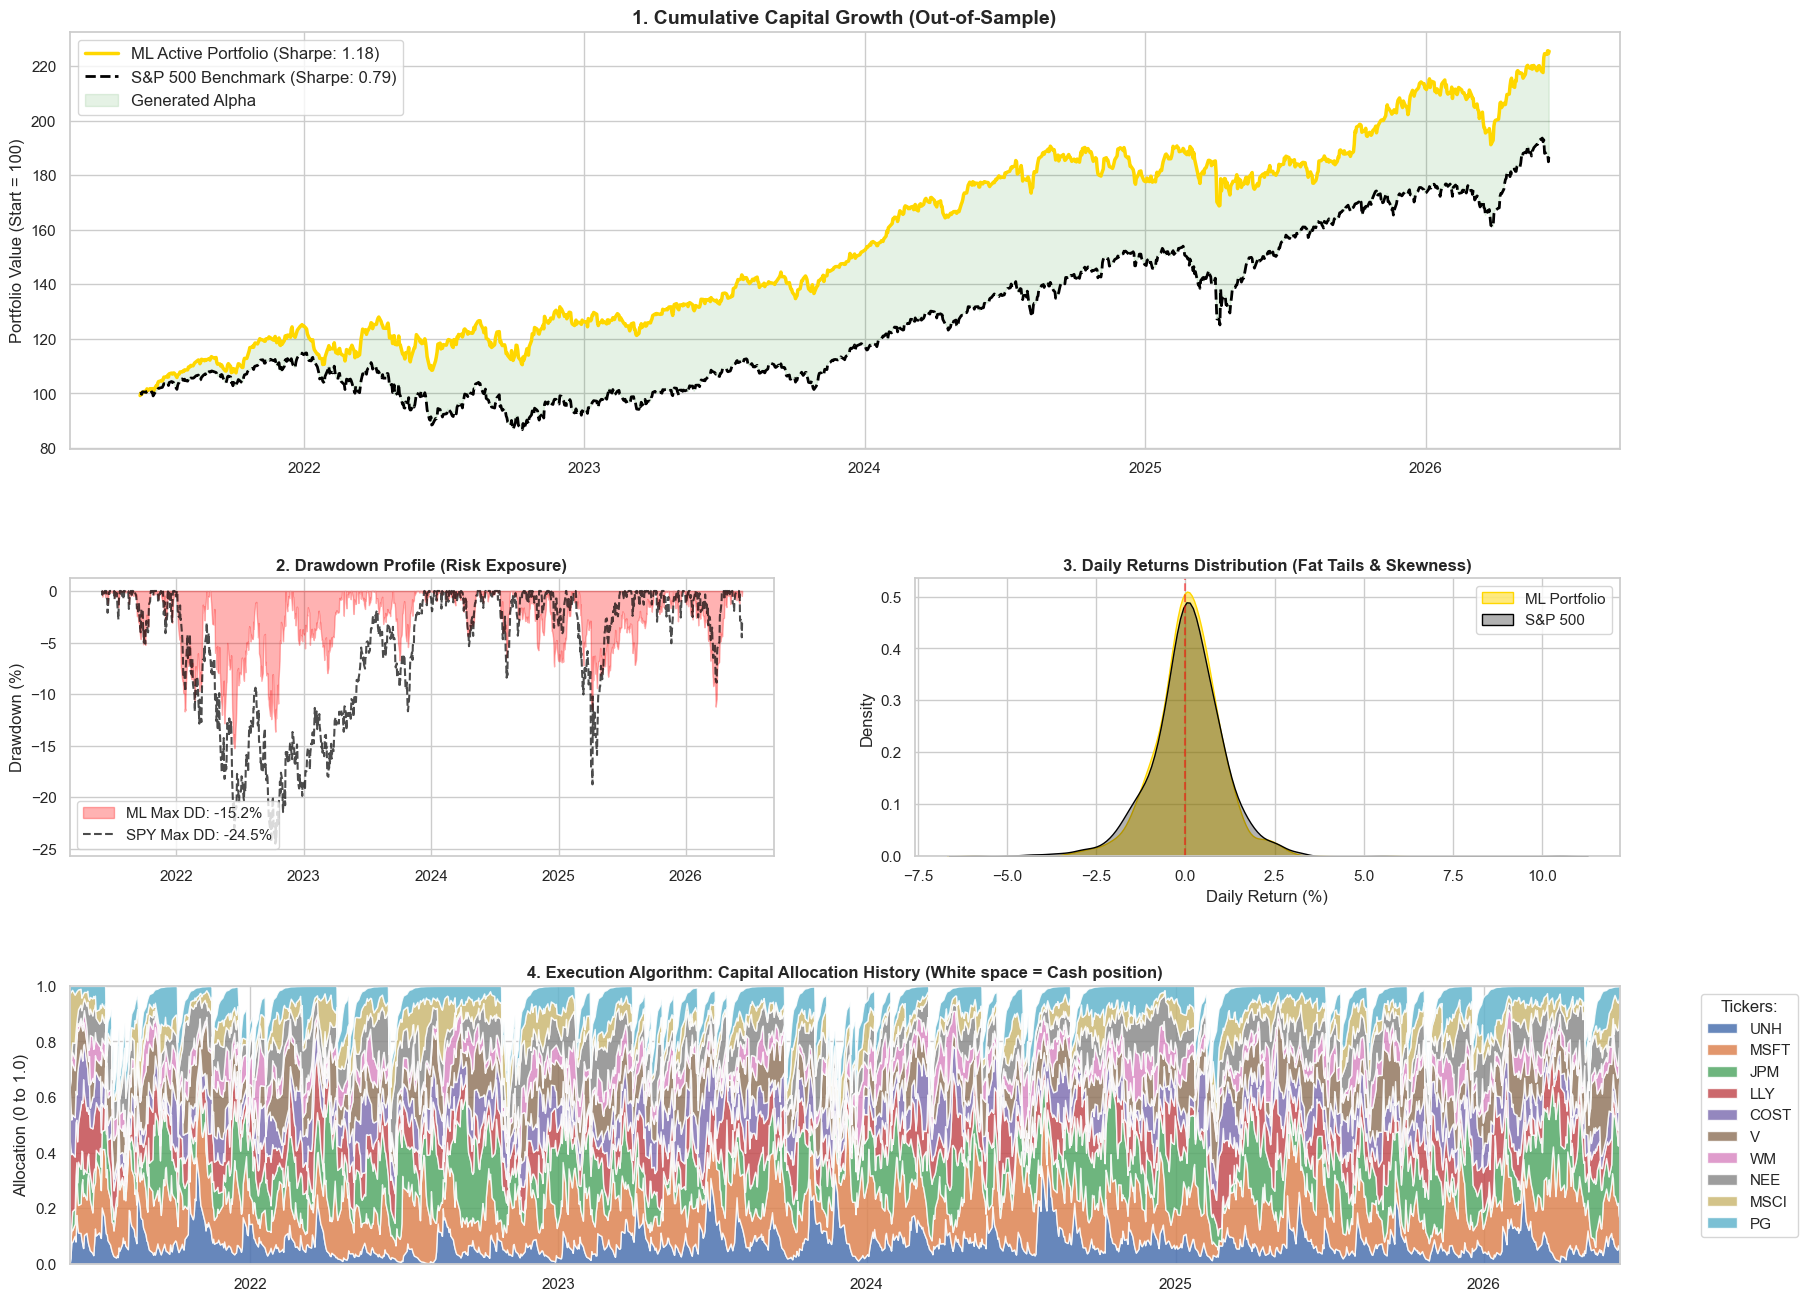

In [1]:
"""
Machine Learning Asset Allocation Simulator.

This script fetches historical stock data, trains a deep neural network to predict 
daily asset returns, and simulates an active trading strategy out-of-sample. 
The active strategy's performance is benchmarked against a static Markowitz 
Optimized portfolio and the S&P 500 (SPY).
"""

import warnings
from typing import List, Tuple

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import yfinance as yf
from pypfopt import EfficientFrontier, expected_returns, risk_models
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


# =========================================================
# 0. CONFIGURATION & DATES
# =========================================================
TRAIN_START: str = "2020-01-01"
SIMULATION_START: str = "2021-06-01"
SIMULATION_END: str = "2026-06-12"

SEQ_LENGTH: int = 60
TICKERS: List[str] = [
    "UNH", "MSFT", "JPM", "LLY", "COST", 
    "V", "WM", "NEE", "MSCI", "PG"
]
NUM_ASSETS: int = len(TICKERS)


# =========================================================
# 1. DATA ACQUISITION & PREPARATION
# =========================================================
print(f"Downloading data from {TRAIN_START} to {SIMULATION_END}...")

# Fetch data and align indices to prevent dimension mismatches
raw_data = yf.download(
    TICKERS + ["SPY"], 
    start=TRAIN_START, 
    end=SIMULATION_END, 
    auto_adjust=True
)['Close'].dropna()

spy_prices = raw_data['SPY']
stock_prices = raw_data.drop(columns=['SPY'])

# Calculate daily returns and scale by 100 for percentage format
returns = stock_prices.pct_change().dropna() * 100
spy_returns = spy_prices.pct_change().dropna() * 100
returns, spy_returns = returns.align(spy_returns, join='inner', axis=0)


# =========================================================
# 2. INITIALIZE BASELINE PORTFOLIO (Markowitz Optimization)
# =========================================================
print("Initializing Baseline Portfolio (Markowitz Optimization)...")

# Isolate training data strictly to avoid data leakage during optimization
train_data_for_opt = stock_prices[:SIMULATION_START].iloc[:-1]

mu = expected_returns.mean_historical_return(train_data_for_opt)
S = risk_models.sample_cov(train_data_for_opt)
ef = EfficientFrontier(mu, S)

raw_weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

# Create static weight vector for the baseline portfolio
static_weights = np.array([cleaned_weights.get(t, 0) for t in TICKERS])


# =========================================================
# 3. FEATURE ENGINEERING & TRAIN/TEST SPLIT
# =========================================================
scaler = StandardScaler()
# Scale returns and clip outliers to stabilize neural network training
scaled_returns = np.clip(scaler.fit_transform(returns.values), -3, 3)

xs: List[np.ndarray] = []
ys_future_ret: List[np.ndarray] = []
valid_dates = returns.index[SEQ_LENGTH:]

# Create sequential batches for training
for i in range(len(scaled_returns) - SEQ_LENGTH):
    xs.append(scaled_returns[i : i + SEQ_LENGTH])
    # Target: The actual return of each asset on day T+1
    ys_future_ret.append(returns.values[i + SEQ_LENGTH])

X = torch.tensor(np.array(xs), dtype=torch.float32)
Y_ret = torch.tensor(np.array(ys_future_ret), dtype=torch.float32)

# Create boolean masks based on the user-defined date parameters
train_mask = valid_dates < SIMULATION_START
test_mask = (valid_dates >= SIMULATION_START) & (valid_dates <= SIMULATION_END)

X_train, Y_train = X[train_mask], Y_ret[train_mask]
X_test, Y_test = X[test_mask], Y_ret[test_mask]

test_dates = valid_dates[test_mask]
spy_test_returns = spy_returns.values[SEQ_LENGTH:][test_mask]

train_loader = DataLoader(
    TensorDataset(X_train, Y_train), 
    batch_size=64, 
    shuffle=True
)


# =========================================================
# 4. NEURAL NETWORK ARCHITECTURE
# =========================================================
class AssetReturnPredictor(nn.Module):
    """
    Feed-forward Neural Network for predicting asset returns based on 
    historical sequential data.
    
    Args:
        num_assets (int): Number of distinct assets to predict.
        seq_length (int): Length of the look-back window (sequence length).
    """
    def __init__(self, num_assets: int, seq_length: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_assets * seq_length, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, num_assets)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the neural network.
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_length, num_assets).
            
        Returns:
            torch.Tensor: Predicted next-day returns of shape (batch_size, num_assets).
        """
        return self.net(x.view(x.size(0), -1))


# =========================================================
# 5. MODEL TRAINING
# =========================================================
model = AssetReturnPredictor(num_assets=NUM_ASSETS, seq_length=SEQ_LENGTH)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
EPOCHS: int = 60

print(f"\nTraining neural network on data before {SIMULATION_START}...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 15 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train MSE Loss: {avg_loss:.4f}")


# =========================================================
# 6. TRADING SIMULATOR (Out-of-Sample)
# =========================================================
print(f"\nStarting Active Trading Simulation ({SIMULATION_START} to {SIMULATION_END})...")
model.eval()

# Start with the baseline optimized weights
current_ml_weights = np.copy(static_weights)
weights_history: List[np.ndarray] = []

ml_daily_returns_list: List[float] = []
static_daily_returns_list: List[float] = []
spy_daily_returns_list: List[float] = []

with torch.no_grad():
    for i in range(len(X_test)):
        # Predict tomorrow's return for each asset
        pred_returns = model(X_test[i:i+1]).numpy()[0]
        
        # Determine target portfolio allocation
        target_weights = np.zeros(NUM_ASSETS)
        positive_indices = pred_returns > 0
        
        # Only buy assets with a predicted positive return
        if np.any(positive_indices):
            target_weights[positive_indices] = (
                pred_returns[positive_indices] / np.sum(pred_returns[positive_indices])
            )

        # Smooth transition: 20% rebalancing per day to mitigate turnover/volatility
        current_ml_weights = 0.8 * current_ml_weights + 0.2 * target_weights
        weights_history.append(current_ml_weights)
        
        # Calculate actual portfolio returns for the day
        actual_daily_returns = Y_test[i].numpy() / 100.0
        
        ml_daily_returns_list.append(np.dot(current_ml_weights, actual_daily_returns))
        static_daily_returns_list.append(np.dot(static_weights, actual_daily_returns))
        spy_daily_returns_list.append(spy_test_returns[i] / 100.0)

# Convert outputs to pandas formats
ml_ret_series = pd.Series(ml_daily_returns_list, index=test_dates)
spy_ret_series = pd.Series(spy_daily_returns_list, index=test_dates)

# Cumulative capital trajectory (Base = 100)
ml_cum_returns = (1 + ml_ret_series).cumprod() * 100
spy_cum_returns = (1 + spy_ret_series).cumprod() * 100

df_weights = pd.DataFrame(weights_history, index=test_dates, columns=TICKERS)


# =========================================================
# 7. QUANTITATIVE METRICS & TEARSHEET
# =========================================================
def calculate_metrics(
    returns_series: pd.Series
) -> Tuple[float, float, float, float, float, float, float, pd.Series]:
    """
    Computes standard quantitative performance metrics for a return series.
    
    Args:
        returns_series (pd.Series): A pandas series of daily percentage returns.
        
    Returns:
        Tuple: Contains cumulative return, CAGR, annualized volatility, 
               Sharpe ratio, max drawdown, Sortino ratio, win rate, 
               and the drawdown time series.
    """
    cum_ret = (1 + returns_series).prod() - 1
    years = len(returns_series) / 252
    cagr = (1 + cum_ret) ** (1 / years) - 1 if years > 0 else 0
    
    volatility = returns_series.std() * np.sqrt(252)
    sharpe = cagr / volatility if volatility > 0 else 0
    
    roll_max = (1 + returns_series).cumprod().cummax()
    drawdown = ((1 + returns_series).cumprod() - roll_max) / roll_max
    max_dd = drawdown.min()
    
    downside_returns = returns_series[returns_series < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = cagr / downside_vol if downside_vol > 0 else 0
    
    win_rate = (returns_series > 0).mean()
    
    return cum_ret, cagr, volatility, sharpe, max_dd, sortino, win_rate, drawdown


(ml_cum, ml_cagr, ml_vol, ml_sharpe, ml_mdd, ml_sortino, ml_win, ml_dd_series) = calculate_metrics(ml_ret_series)
(spy_cum, spy_cagr, spy_vol, spy_sharpe, spy_mdd, spy_sortino, spy_win, spy_dd_series) = calculate_metrics(spy_ret_series)

print("\n" + "="*65)
print(f"{'METRIC':<25} | {'ML PORTFOLIO':<15} | {'S&P 500 (SPY)':<15}")
print("-" * 65)
print(f"{'Cumulative Return':<25} | {ml_cum*100:>14.2f}% | {spy_cum*100:>14.2f}%")
print(f"{'Annualized Return (CAGR)':<25} | {ml_cagr*100:>14.2f}% | {spy_cagr*100:>14.2f}%")
print(f"{'Annualized Volatility':<25} | {ml_vol*100:>14.2f}% | {spy_vol*100:>14.2f}%")
print(f"{'Sharpe Ratio':<25} | {ml_sharpe:>14.2f}  | {spy_sharpe:>14.2f} ")
print(f"{'Sortino Ratio':<25} | {ml_sortino:>14.2f}  | {spy_sortino:>14.2f} ")
print(f"{'Maximum Drawdown':<25} | {ml_mdd*100:>14.2f}% | {spy_mdd*100:>14.2f}%")
print(f"{'Daily Win Rate':<25} | {ml_win*100:>14.2f}% | {spy_win*100:>14.2f}%")
print("="*65)


# =========================================================
# 8. VISUALIZATION DASHBOARD
# =========================================================
print("\nGenerating Analytics Dashboard...")
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.5, 1, 1], hspace=0.4, wspace=0.2)

# --- PLOT 1: Cumulative Equity Curve ---
ax0 = plt.subplot(gs[0, :])
ax0.plot(
    ml_cum_returns.index, ml_cum_returns, 
    color='gold', lw=2.5, 
    label=f'ML Active Portfolio (Sharpe: {ml_sharpe:.2f})'
)
ax0.plot(
    spy_cum_returns.index, spy_cum_returns, 
    color='black', linestyle='--', lw=2, 
    label=f'S&P 500 Benchmark (Sharpe: {spy_sharpe:.2f})'
)
ax0.set_title("1. Cumulative Capital Growth (Out-of-Sample)", fontweight='bold', fontsize=14)
ax0.set_ylabel("Portfolio Value (Start = 100)")
ax0.fill_between(
    ml_cum_returns.index, ml_cum_returns, spy_cum_returns, 
    where=(ml_cum_returns > spy_cum_returns), 
    interpolate=True, color='green', alpha=0.1, label='Generated Alpha'
)
ax0.legend(loc='upper left', fontsize=12)

# --- PLOT 2: Drawdown Profile ---
ax1 = plt.subplot(gs[1, 0])
ax1.fill_between(
    ml_dd_series.index, ml_dd_series * 100, 0, 
    color='red', alpha=0.3, label=f'ML Max DD: {ml_mdd*100:.1f}%'
)
ax1.plot(
    spy_dd_series.index, spy_dd_series * 100, 
    color='black', linestyle='--', alpha=0.7, 
    label=f'SPY Max DD: {spy_mdd*100:.1f}%'
)
ax1.set_title("2. Drawdown Profile (Risk Exposure)", fontweight='bold')
ax1.set_ylabel("Drawdown (%)")
ax1.legend(loc='lower left')

# --- PLOT 3: Daily Returns Distribution ---
ax2 = plt.subplot(gs[1, 1])
sns.kdeplot(
    ml_ret_series * 100, ax=ax2, 
    color='gold', fill=True, label='ML Portfolio', alpha=0.5
)
sns.kdeplot(
    spy_ret_series * 100, ax=ax2, 
    color='black', fill=True, label='S&P 500', alpha=0.3
)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_title("3. Daily Returns Distribution (Fat Tails & Skewness)", fontweight='bold')
ax2.set_xlabel("Daily Return (%)")
ax2.set_ylabel("Density")
ax2.legend()

# --- PLOT 4: Dynamic Capital Allocation ---
ax3 = plt.subplot(gs[2, :])
ax3.stackplot(test_dates, df_weights.T, labels=TICKERS, alpha=0.85, cmap='tab10')
ax3.set_title(
    "4. Execution Algorithm: Capital Allocation History (White space = Cash position)", 
    fontweight='bold'
)
ax3.set_ylabel("Allocation (0 to 1.0)")
ax3.margins(x=0)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right', bbox_to_anchor=(1.12, 1), title="Tickers:")

plt.show()

[*********************100%***********************]  11 of 11 completed


Optimizing portfolio (Max Sharpe)...
Generating Portfolio Visualization Suite...


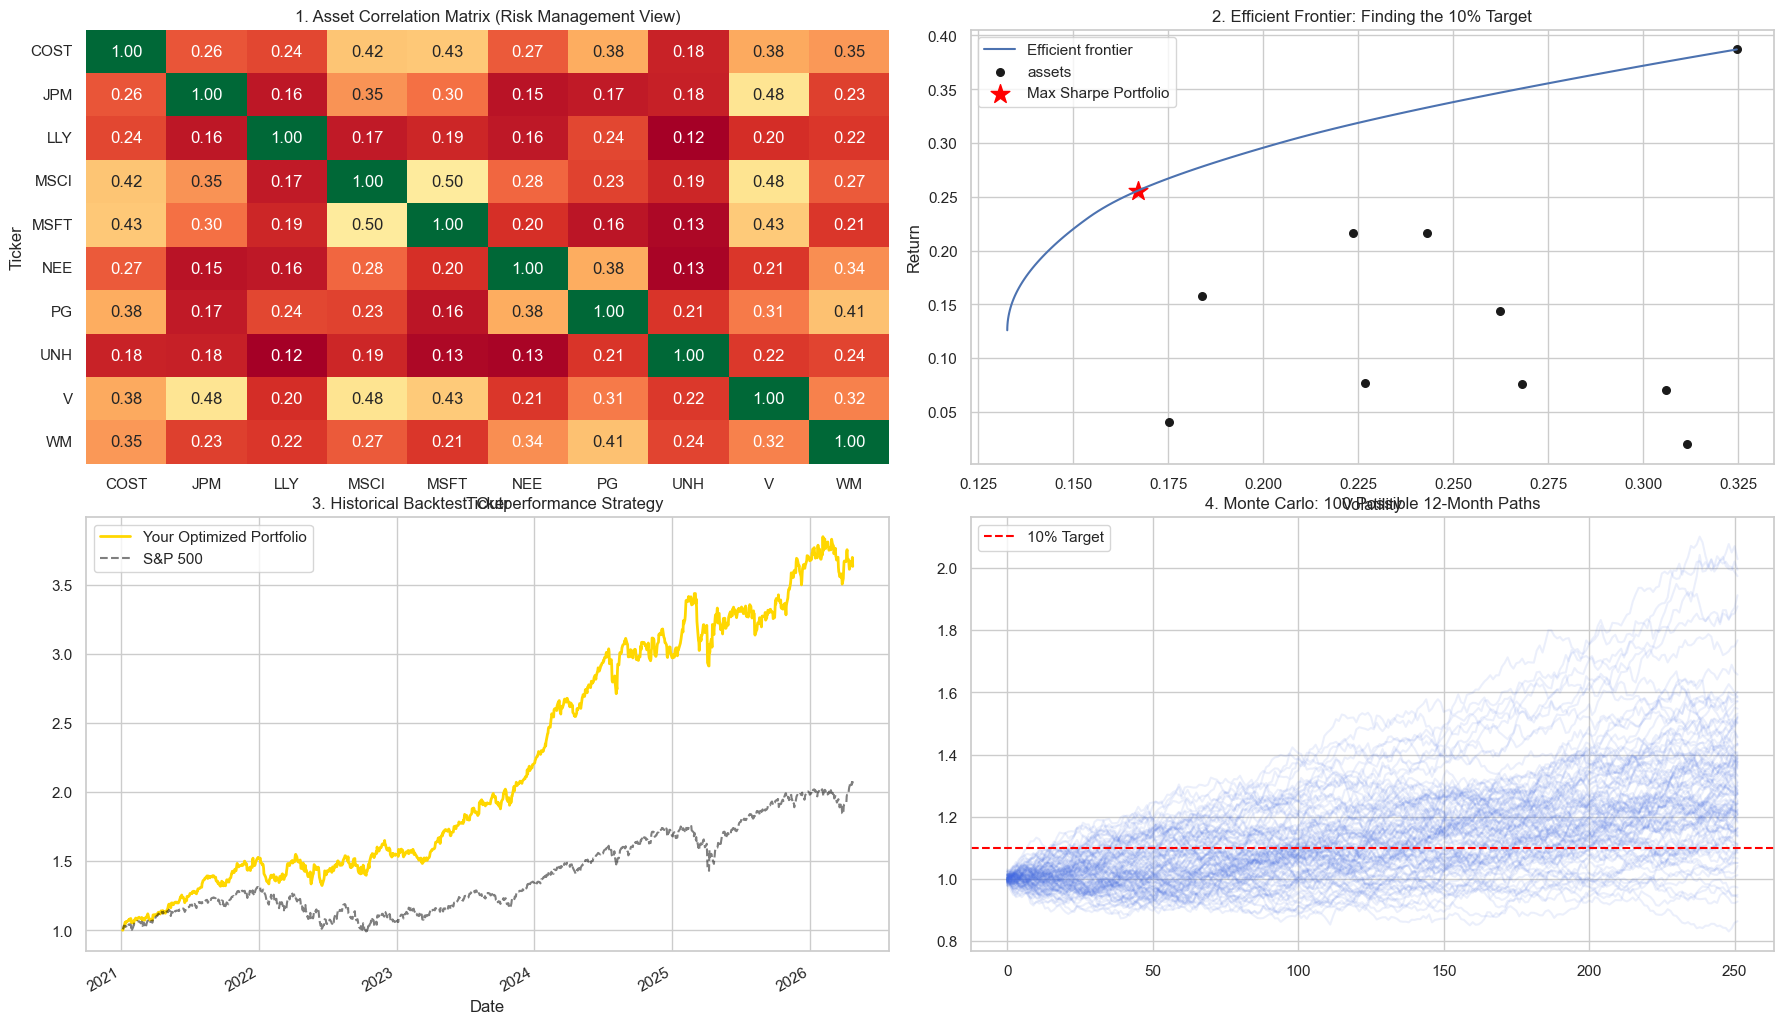


--- Running Prophet ML Forecast for Core Asset: MSFT ---


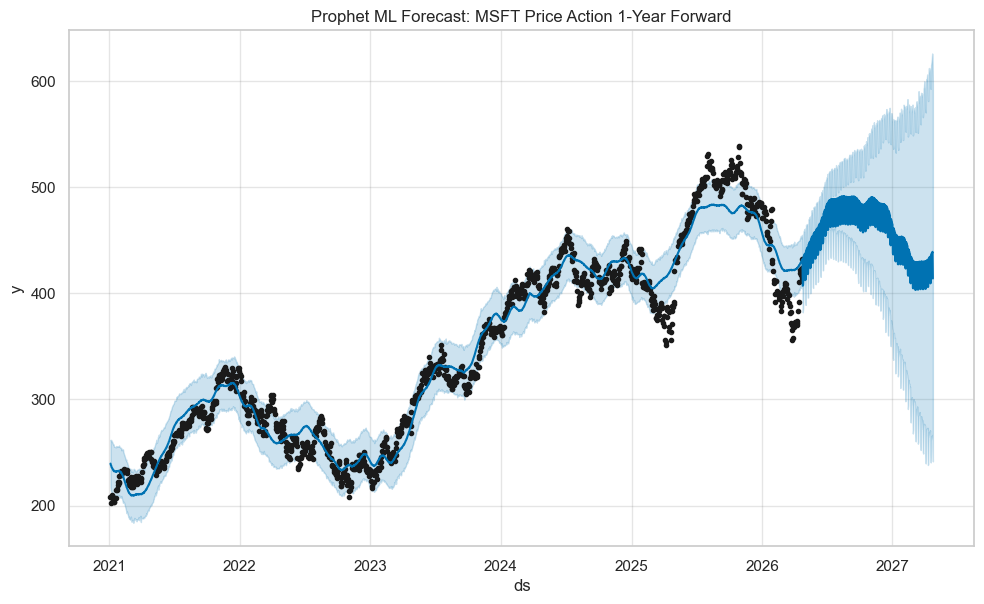


Ticker   | Weight (%)   | Monthly Target Allocation
------------------------------------------------------------
COST     |      23.34% | $            116.72
JPM      |      24.07% | $            120.38
LLY      |      30.63% | $            153.12
WM       |      21.95% | $            109.77

--- Modeling S&P 500 (SPY) using LSTM and tracking via MLflow ---
Starting LSTM network training...
Epoch [10/30], Loss: 0.003790
Epoch [20/30], Loss: 0.001042


2026/06/19 21:55:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 21:55:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch [30/30], Loss: 0.001698
Training completed. Final test error (MSE): 0.002514

[INFO] Logs and model weights saved to MLflow.
[INFO] To view the analytics dashboard, run 'mlflow ui' in your terminal.


In [2]:
"""
Advanced Quantitative Portfolio Manager & Forecasting Suite.

This script performs end-to-end financial data analysis by integrating Modern 
Portfolio Theory (PyPortfolioOpt) for asset allocation, Facebook Prophet for 
individual stock time-series forecasting, and a PyTorch LSTM neural network 
tracked via MLflow to predict S&P 500 index movements.
"""

import warnings
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import yfinance as yf
from prophet import Prophet
from pypfopt import EfficientFrontier, expected_returns, plotting, risk_models
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Suppress warnings for a cleaner output report
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


# =========================================================
# 0. CONFIGURATION & HYPERPARAMETERS
# =========================================================
START_DATE: str = "2021-01-01"
END_DATE: str = "2026-04-27"
TICKERS: List[str] = [
    "UNH", "MSFT", "JPM", "LLY", "COST", 
    "V", "WM", "NEE", "MSCI", "PG"
]
MONTHLY_BUDGET: float = 500.0

# LSTM Configuration
SEQ_LENGTH: int = 20
HIDDEN_SIZE: int = 64
NUM_LAYERS: int = 2
EPOCHS: int = 30
LEARNING_RATE: float = 0.001
BATCH_SIZE: int = 32


# =========================================================
# 1. DATA ACQUISITION & CLEANING
# =========================================================
print(f"Downloading data from {START_DATE} to {END_DATE}...")
raw_data = yf.download(
    TICKERS + ["SPY"], 
    start=START_DATE, 
    end=END_DATE, 
    auto_adjust=True
)
data = raw_data['Close'].dropna()

# Separate S&P 500 (benchmark) from portfolio stocks
spy_bench = data['SPY']
stocks_data = data.drop(columns=['SPY'])


# =========================================================
# 2. PORTFOLIO CALCULATION (PyPortfolioOpt)
# =========================================================
print("Optimizing portfolio (Max Sharpe)...")
mu = expected_returns.mean_historical_return(stocks_data)
S = risk_models.sample_cov(stocks_data)

ef_for_solving = EfficientFrontier(mu, S)
ef_for_plotting = EfficientFrontier(mu, S)

weights = ef_for_solving.max_sharpe()
cleaned_weights: Dict[str, float] = ef_for_solving.clean_weights()


# =========================================================
# 3. VISUALIZATION SUITE
# =========================================================
print("Generating Portfolio Visualization Suite...")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# PLOT 1: Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(
    stocks_data.pct_change().corr(), 
    annot=True, cmap='RdYlGn', fmt=".2f", cbar=False
)
plt.title("1. Asset Correlation Matrix (Risk Management View)")

# PLOT 2: Efficient Frontier
ax_ef = plt.subplot(2, 2, 2)
plotting.plot_efficient_frontier(ef_for_plotting, ax=ax_ef, show_assets=True)
ret_tangent, std_tangent, _ = ef_for_solving.portfolio_performance()
ax_ef.scatter(
    std_tangent, ret_tangent, 
    marker="*", s=200, c="red", label="Max Sharpe Portfolio"
)
plt.title("2. Efficient Frontier: Finding the 10% Target")
plt.legend()

# PLOT 3: Cumulative Performance vs. S&P 500
plt.subplot(2, 2, 3)
port_rets = (stocks_data.pct_change() * pd.Series(cleaned_weights)).sum(axis=1)
((1 + port_rets).cumprod()).plot(label="Your Optimized Portfolio", color='gold', lw=2)
((1 + spy_bench.pct_change()).cumprod()).plot(label="S&P 500", color='black', alpha=0.5, linestyle='--')
plt.title("3. Historical Backtest: Outperformance Strategy")
plt.legend()

# PLOT 4: Monte Carlo 12-Month Forecast
plt.subplot(2, 2, 4)
DAYS_TO_FORECAST = 252
SIMULATIONS = 100
mu_daily = stocks_data.pct_change().mean()
cov_daily = stocks_data.pct_change().cov()

for _ in range(SIMULATIONS):
    sim_rets = np.random.multivariate_normal(mu_daily, cov_daily, DAYS_TO_FORECAST)
    sim_port_rets = sim_rets.dot(list(cleaned_weights.values()))
    plt.plot(np.cumprod(1 + sim_port_rets), color='royalblue', alpha=0.1)

plt.axhline(1.10, color='red', linestyle='--', label='10% Target')
plt.title("4. Monte Carlo: 100 Possible 12-Month Paths")
plt.legend()

plt.show()


# =========================================================
# 4. ML INDIVIDUAL STOCK FORECAST (Prophet)
# =========================================================
print("\n--- Running Prophet ML Forecast for Core Asset: MSFT ---")
msft_df = stocks_data['MSFT'].reset_index()
msft_df.columns = ['ds', 'y']
msft_df['ds'] = msft_df['ds'].dt.tz_localize(None)

model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_prophet.fit(msft_df)
future = model_prophet.make_future_dataframe(periods=365)
forecast = model_prophet.predict(future)

fig_ml = model_prophet.plot(forecast)
plt.title("Prophet ML Forecast: MSFT Price Action 1-Year Forward")
plt.show()


# =========================================================
# 5. FINAL EXECUTION TABLE
# =========================================================
print("\n" + "="*60)
print(f"{'Ticker':<8} | {'Weight (%)':<12} | {'Monthly Target Allocation'}")
print("-" * 60)
for ticker, weight in cleaned_weights.items():
    if weight > 0.01:
        allocation = weight * MONTHLY_BUDGET
        print(f"{ticker:<8} | {weight*100:>10.2f}% | ${allocation:>18.2f}")
print("="*60)


# =========================================================
# 6. S&P 500 PREDICTION USING PYTORCH LSTM & MLFLOW
# =========================================================
print("\n--- Modeling S&P 500 (SPY) using LSTM and tracking via MLflow ---")

# 6.1 Data Preparation
spy_data = spy_bench.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
spy_scaled = scaler.fit_transform(spy_data)

def create_sequences(
    data_array: np.ndarray, 
    seq_length: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Converts a 1D timeseries array into sequential windows for LSTM training.
    
    Args:
        data_array (np.ndarray): Scaled time series data.
        seq_length (int): The number of historical steps to include in one sequence.
        
    Returns:
        Tuple[np.ndarray, np.ndarray]: X (sequences) and y (targets).
    """
    xs, ys = [], []
    for i in range(len(data_array) - seq_length):
        xs.append(data_array[i : i + seq_length])
        ys.append(data_array[i + seq_length])
    return np.array(xs), np.array(ys)


X, y = create_sequences(spy_scaled, SEQ_LENGTH)

train_size = int(len(X) * 0.8)
X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32)
X_test = torch.tensor(X[train_size:], dtype=torch.float32)
y_test = torch.tensor(y[train_size:], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train), 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

# 6.2 LSTM Architecture Definition
class SPYPredictorLSTM(nn.Module):
    """
    Long Short-Term Memory (LSTM) network for univariate time series forecasting.
    
    Args:
        input_size (int): Number of expected features in the input (1 for SPY).
        hidden_size (int): Number of features in the hidden state.
        num_layers (int): Number of recurrent layers.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        # Extract the hidden state from the last time step
        out = self.fc(out[:, -1, :]) 
        return out

# 6.3 Model Initialization
model_lstm = SPYPredictorLSTM(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

# 6.4 MLflow Integration & Training Loop
mlflow.set_experiment("SP500_Prediction_LSTM")

with mlflow.start_run(run_name="LSTM_Base_Architecture"):
    
    mlflow.log_params({
        "sequence_length": SEQ_LENGTH,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "loss_function": "MSELoss"
    })
    
    print("Starting LSTM network training...")
    model_lstm.train()
    
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model_lstm(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_train_loss = epoch_loss / len(train_loader)
        mlflow.log_metric("train_mse", avg_train_loss, step=epoch)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_train_loss:.6f}")

    # 6.5 Test Evaluation
    model_lstm.eval()
    with torch.no_grad():
        test_predictions = model_lstm(X_test)
        test_loss = criterion(test_predictions, y_test)
        
    mlflow.log_metric("test_mse", test_loss.item())
    print(f"Training completed. Final test error (MSE): {test_loss.item():.6f}")

    # 6.6 Save Signature and Model in MLflow
    signature = mlflow.models.signature.infer_signature(
        X_train.numpy(), 
        model_lstm(X_train).detach().numpy()
    )
    mlflow.pytorch.log_model(model_lstm, "spy_lstm_model", signature=signature)
    
    print("\n[INFO] Logs and model weights saved to MLflow.")
    print("[INFO] To view the analytics dashboard, run 'mlflow ui' in your terminal.")

[**************        30%                       ]  3 of 10 completed

--- Fetching Market Data for 10 Assets ---


[*********************100%***********************]  10 of 10 completed



--- Current Market Entry Prices (OOS Spot) ---
Ticker
AVGO     422.76
BRK-B    469.32
JNJ      226.20
JPM      308.28
MSFT     423.70
NEE       94.59
NVO       41.17
O         62.78
TSM      401.52
V        308.78
Name: 2026-04-24 00:00:00, dtype: float64

Executing Mean-Variance Optimization (Max Sharpe Index)...
Running 100 Stochastic Paths for Future DCA Projections...


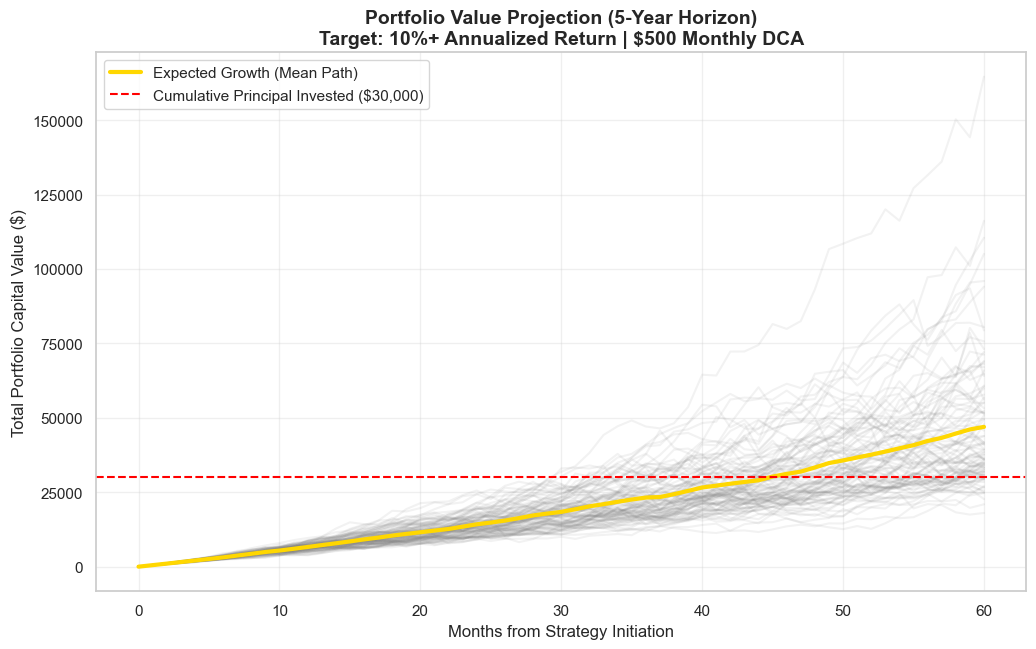


Ticker   | Opt. Weight  | Monthly Buy Allocation
------------------------------------------------------------
AVGO     |      34.72% | $            173.61
BRK-B    |      13.54% | $             67.70
JNJ      |      39.19% | $            195.93
JPM      |      12.55% | $             62.77


In [3]:
"""
Multi-Asset Portfolio Optimization and Dollar-Cost Averaging (DCA) Simulator.

This script pulls historical market data for a diversified 10-asset universe, 
calculates optimal portfolio weights using the Modern Portfolio Theory (Max Sharpe) 
framework via PyPortfolioOpt, and runs a forward-looking Monte Carlo simulation 
to project future capital accumulation under a fixed monthly DCA strategy.
"""

from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import EfficientFrontier, expected_returns, risk_models

# =========================================================
# 0. CONFIGURATION & INVESTMENT PARAMETERS
# =========================================================
START_DATE: str = "2021-01-01"
END_DATE: str = "2026-04-27"

# Tickers selected for optimal long-term risk-adjusted growth
TICKERS: List[str] = [
    "JPM", "MSFT", "V", "JNJ", "BRK-B", 
    "NEE", "O", "AVGO", "NVO", "TSM"
]

MONTHLY_INVESTMENT: float = 500.0
FORECAST_MONTHS: int = 60
NUM_SIMULATIONS: int = 100


# =========================================================
# 1. DATA ACQUISITION & CLEANING
# =========================================================
print(f"--- Fetching Market Data for {len(TICKERS)} Assets ---")
raw_data = yf.download(
    TICKERS, 
    start=START_DATE, 
    end=END_DATE, 
    auto_adjust=True
)
data = raw_data['Close'].dropna()


# =========================================================
# 2. CURRENT MARKET ENTRY PRICING
# =========================================================
latest_prices = data.iloc[-1]
print("\n--- Current Market Entry Prices (OOS Spot) ---")
print(latest_prices.round(2))


# =========================================================
# 3. PORTFOLIO OPTIMIZATION (PyPortfolioOpt)
# =========================================================
print("\nExecuting Mean-Variance Optimization (Max Sharpe Index)...")
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights: Dict[str, float] = ef.clean_weights()


# =========================================================
# 4. FORWARD PROJECTION & MONTE CARLO SIMULATION
# =========================================================
print(f"Running {NUM_SIMULATIONS} Stochastic Paths for Future DCA Projections...")

# Convert annualized metrics down to monthly frequencies
mean_monthly_return = float(np.mean(mu) / 12)
std_monthly_return = float(np.sqrt(np.diag(S)).mean() / np.sqrt(12))

plt.figure(figsize=(12, 7))

all_sim_paths: List[List[float]] = []

for i in range(NUM_SIMULATIONS):
    portfolio_value: List[float] = [0.0]
    for month in range(1, FORECAST_MONTHS + 1):
        # Sample normal distribution using asset universe baseline volatility
        growth = np.random.normal(mean_monthly_return, std_monthly_return)
        new_value = (portfolio_value[-1] + MONTHLY_INVESTMENT) * (1 + growth)
        portfolio_value.append(new_value)
        
    all_sim_paths.append(portfolio_value)
    plt.plot(portfolio_value, color='gray', alpha=0.1)

# Statistical aggregation over generated paths
mean_path = np.mean(all_sim_paths, axis=0)
principal_invested = MONTHLY_INVESTMENT * FORECAST_MONTHS

# Visualization Design
plt.plot(
    mean_path, 
    color='gold', linewidth=3, 
    label='Expected Growth (Mean Path)'
)
plt.axhline(
    y=principal_invested, 
    color='red', linestyle='--', 
    label=f'Cumulative Principal Invested (${int(principal_invested):,})'
)

plt.title(
    f"Portfolio Value Projection (5-Year Horizon)\n"
    f"Target: 10%+ Annualized Return | ${int(MONTHLY_INVESTMENT)} Monthly DCA", 
    fontsize=14, fontweight='bold'
)
plt.xlabel("Months from Strategy Initiation")
plt.ylabel("Total Portfolio Capital Value ($)")
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# 5. EXECUTION & TARGET ALLOCATION TABLE
# =========================================================
print("\n" + "="*60)
print(f"{'Ticker':<8} | {'Opt. Weight':<12} | {'Monthly Buy Allocation'}")
print("-" * 60)
for ticker, weight in cleaned_weights.items():
    if weight > 0:
        target_buy = weight * MONTHLY_INVESTMENT
        print(f"{ticker:<8} | {weight*100:>10.2f}% | ${target_buy:>18.2f}")
print("="*60)

[*********************100%***********************]  10 of 10 completed


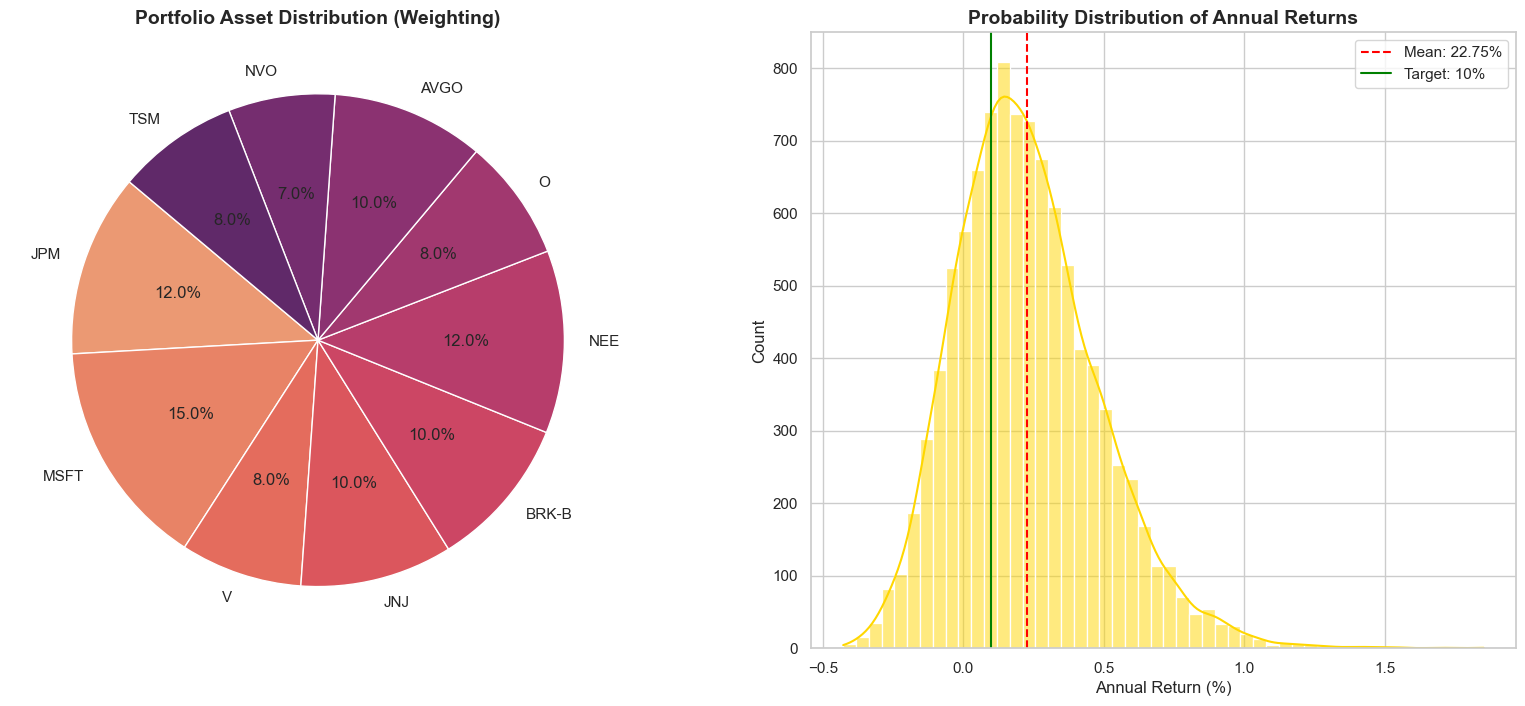

95% Confidence Interval: Annual returns are likely to be above -13.97%


: 

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & DATA (Using the 2026 verified tickers)
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2020-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
returns = data.pct_change().dropna()

# 2. ASSIGN WEIGHTS (Based on our XGBoost/MPT blend)
weights = np.array([0.12, 0.15, 0.08, 0.10, 0.10, 0.12, 0.08, 0.10, 0.07, 0.08])

# 3. VISUALIZATION DASHBOARD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PLOT A: ASSET WEIGHT DISTRIBUTION
colors = sns.color_palette("flare", len(tickers))
ax1.pie(weights, labels=tickers, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
ax1.set_title("Portfolio Asset Distribution (Weighting)", fontsize=14, fontweight='bold')

# PLOT B: PROBABILITY DISTRIBUTION OF RETURNS (Monte Carlo)
# Simulating 10,000 possible annual return scenarios
sim_returns = []
mean_ret = returns.mean()
cov_matrix = returns.cov()

for i in range(10000):
    # Random sample from the multivariate normal distribution
    random_rets = np.random.multivariate_normal(mean_ret, cov_matrix, 252)
    annual_port_ret = (np.dot(random_rets, weights) + 1).prod() - 1
    sim_returns.append(annual_port_ret)

sns.histplot(sim_returns, kde=True, ax=ax2, color='gold', bins=50)
ax2.axvline(np.mean(sim_returns), color='red', linestyle='--', label=f'Mean: {np.mean(sim_returns):.2%}')
ax2.axvline(0.10, color='green', linestyle='-', label='Target: 10%')
ax2.set_title("Probability Distribution of Annual Returns", fontsize=14, fontweight='bold')
ax2.set_xlabel("Annual Return (%)")
ax2.legend()

plt.show()

# 4. RISK METRIC: VALUE AT RISK (VaR)
var_95 = np.percentile(sim_returns, 5)
print(f"95% Confidence Interval: Annual returns are likely to be above {var_95:.2%}")

--- Fetching Multi-Asset Portfolio Data (2026 Feed) ---


[*********************100%***********************]  10 of 10 completed


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2644.91
Distribution:      Standardized Student's t   AIC:                           5299.83
Method:                  Maximum Likelihood   BIC:                           5327.41
                                              No. Observations:                 1837
Date:                      Fri, Jun 19 2026   Df Residuals:                     1836
Time:                              21:57:35   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

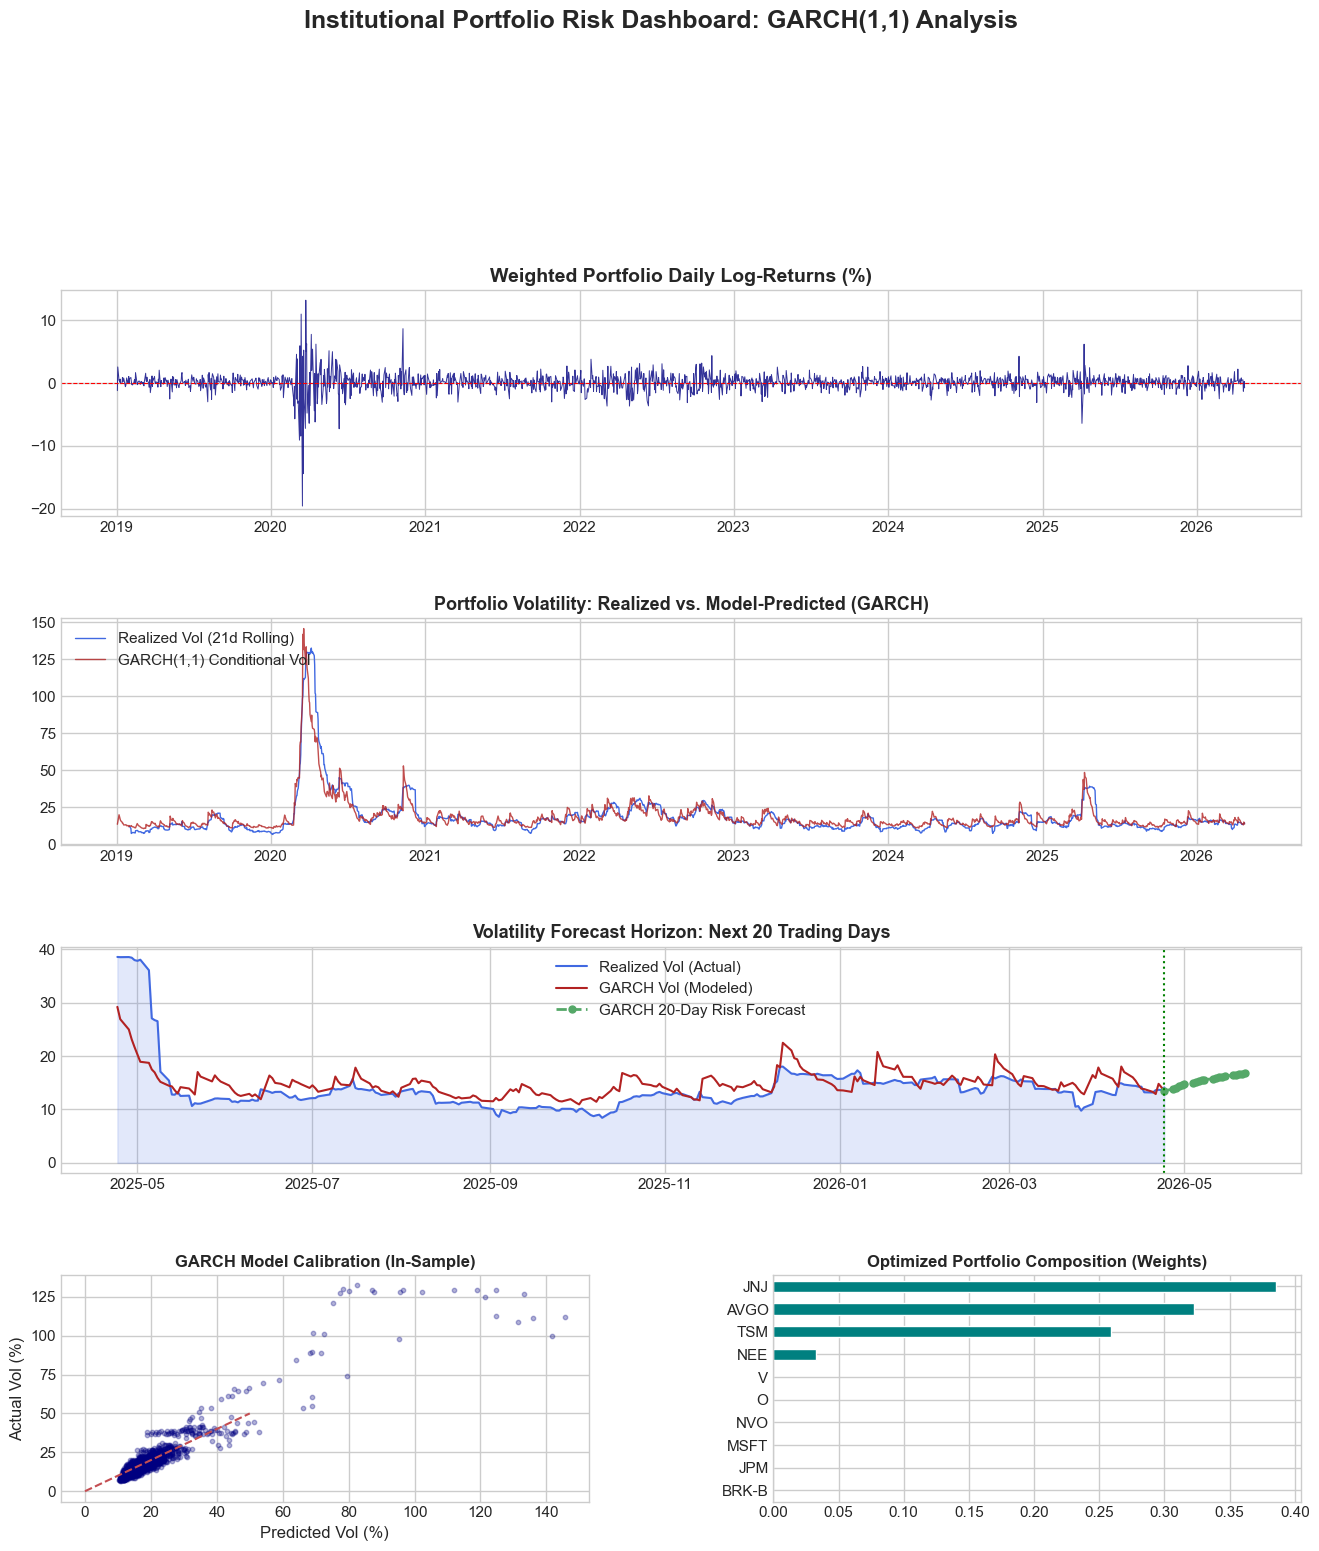

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from arch import arch_model
from scipy import stats
from pypfopt import EfficientFrontier, risk_models, expected_returns

# --- 1. CONFIGURATION ---
TICKERS = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
REALIZED_WINDOW  = 21        # 1-month rolling realized vol
ANNUALIZE_FACTOR = np.sqrt(252)
FORECAST_HORIZON = 20        # Next 20 trading days
TAIL_HISTORY     = 252       # 1 Year of history in zoom plot

# --- 2. DATA ACQUISITION & PORTFOLIO WEIGHTING ---
print("--- Fetching Multi-Asset Portfolio Data (2026 Feed) ---")
data = yf.download(TICKERS, start="2019-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()

# Calculate 'Best Weights' using Max Sharpe (Institutional Default)
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu, S)
weights_dict = ef.max_sharpe()
weights = np.array([weights_dict[t] for t in TICKERS])

# Calculate Weighted Portfolio Log-Returns (Scaled by 100 for GARCH stability)
individual_returns = 100 * np.log(data / data.shift(1)).dropna()
portfolio_returns = (individual_returns * weights).sum(axis=1)

# --- 3. VOLATILITY CALCULATION (RV vs GARCH) ---
# Realized Volatility (Rolling Std * Sqrt(252))
realized_vol = portfolio_returns.rolling(window=REALIZED_WINDOW).std() * ANNUALIZE_FACTOR

# Fit GARCH(1,1) with Student's t-distribution for 2026 "Fat Tail" risks
model = arch_model(portfolio_returns, vol='Garch', p=1, q=1, dist='t')
model_fit = model.fit(disp='off')
print(model_fit.summary())

# Conditional Volatility (In-sample, Annualized)
cond_vol_ann = model_fit.conditional_volatility * ANNUALIZE_FACTOR

# --- 4. FORECASTING ---
forecasts = model_fit.forecast(horizon=FORECAST_HORIZON, reindex=False)
# Daily Variance -> Annualized Vol %
forecast_vol = np.sqrt(forecasts.variance.values[-1, :]) * ANNUALIZE_FACTOR

last_date = portfolio_returns.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=FORECAST_HORIZON + 1, freq='B')[1:]
forecast_series = pd.Series(forecast_vol, index=forecast_dates)

# --- 5. THE MASTER DASHBOARD ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Portfolio Log-Returns
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(portfolio_returns, color='navy', lw=0.7, alpha=0.8)
ax1.set_title('Weighted Portfolio Daily Log-Returns (%)', fontsize=14, fontweight='bold')
ax1.axhline(0, color='red', lw=0.8, ls='--')

# Plot 2: Realized vs GARCH Volatility (Full History)
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(realized_vol, color='royalblue', lw=1, label='Realized Vol (21d Rolling)')
ax2.plot(cond_vol_ann, color='firebrick', lw=1, label='GARCH(1,1) Conditional Vol', alpha=0.8)
ax2.set_title('Portfolio Volatility: Realized vs. Model-Predicted (GARCH)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')

# Plot 3: 1-Year Zoom + 20-Day Forward Forecast
ax3 = fig.add_subplot(gs[2, :])
rv_tail = realized_vol.tail(TAIL_HISTORY)
cv_tail = cond_vol_ann.reindex(rv_tail.index)

ax3.fill_between(rv_tail.index, rv_tail, alpha=0.15, color='royalblue')
ax3.plot(rv_tail, color='royalblue', lw=1.5, label='Realized Vol (Actual)')
ax3.plot(cv_tail, color='firebrick', lw=1.5, label='GARCH Vol (Modeled)')

# Plotting the Forecast "Step-out"
forecast_x = [cv_tail.index[-1]] + list(forecast_series.index)
forecast_y = [cv_tail.iloc[-1]] + list(forecast_series.values)
ax3.plot(forecast_x, forecast_y, 'g--o', lw=2, ms=5, label='GARCH 20-Day Risk Forecast')

ax3.axvline(last_date, color='green', ls=':', lw=1.5)
ax3.set_title(f'Volatility Forecast Horizon: Next 20 Trading Days', fontsize=13, fontweight='bold')
ax3.legend()

# Plot 4: Scatter Plot (Accuracy Check)
ax4 = fig.add_subplot(gs[3, 0])
common_idx = realized_vol.dropna().index.intersection(cond_vol_ann.index)
ax4.scatter(cond_vol_ann[common_idx], realized_vol[common_idx], s=10, color='navy', alpha=0.3)
ax4.plot([0, 50], [0, 50], 'r--', label='Perfect Calibration')
ax4.set_title('GARCH Model Calibration (In-Sample)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicted Vol (%)')
ax4.set_ylabel('Actual Vol (%)')

# Plot 5: Weight Distribution Summary
ax5 = fig.add_subplot(gs[3, 1])
pd.Series(weights_dict).sort_values().plot(kind='barh', ax=ax5, color='teal')
ax5.set_title('Optimized Portfolio Composition (Weights)', fontsize=12, fontweight='bold')

fig.suptitle('Institutional Portfolio Risk Dashboard: GARCH(1,1) Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.show()

[*********************100%***********************]  10 of 10 completed


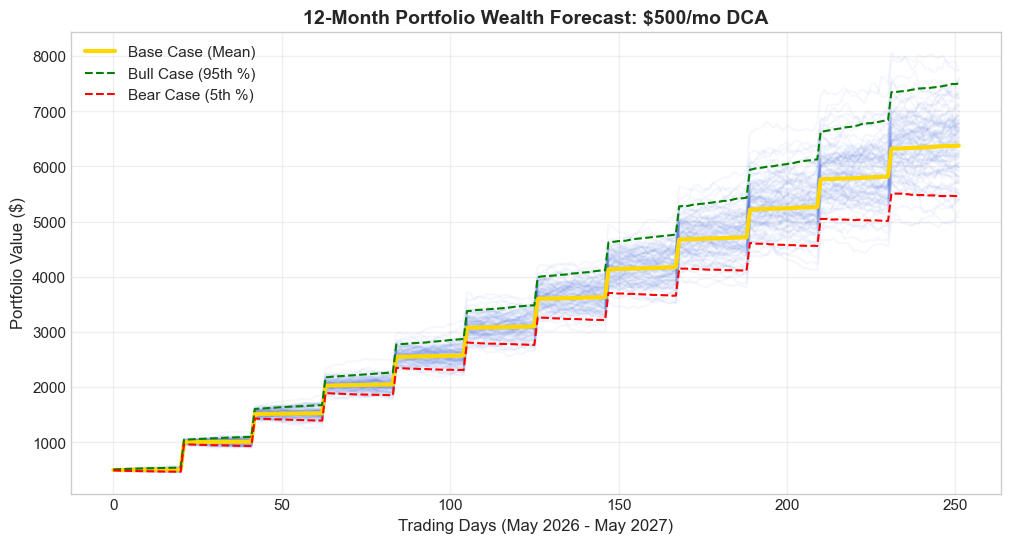

--- 12-Month Forecasted Outcomes ---
Expected Value: $6,412.15
95% Confidence Range: $5,459.70 to $7,503.98
Probability of beating 10% Return: 36.4%


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# 1. DATA & LOG-RETURNS
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2020-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
weights = np.array([0.1] * 10) # Using equal-weight for forecast stability or use optimized weights
port_rets = (data.pct_change().dropna() * weights).sum(axis=1)

# 2. GARCH VOLATILITY INJECTION
# We use GARCH to get the 'Starting Volatility' for our forecast
model = arch_model(port_rets * 100, p=1, q=1, vol='Garch', dist='t')
res = model.fit(disp='off')
forecast_vol_daily = np.sqrt(res.forecast(horizon=1).variance.values[-1, 0]) / 100

# 3. MONTE CARLO SIMULATION (12 Months / 252 Days)
days = 252
sims = 10000
monthly_inv = 500
# Expected daily drift (12% annual target)
daily_drift = 0.12 / 252 

# Simulation Matrix
paths = np.zeros((days, sims))
for i in range(sims):
    # Random walk with GARCH-starting volatility
    shocks = np.random.standard_t(df=res.params['nu'], size=days) * forecast_vol_daily
    daily_rets = daily_drift + shocks
    
    # Wealth accumulation with $500 monthly DCA (approx every 21 days)
    wealth = 0
    path = []
    for d in range(days):
        if d % 21 == 0: wealth += monthly_inv
        wealth *= (1 + daily_rets[d])
        path.append(wealth)
    paths[:, i] = path

# 4. VISUALIZATION OF THE "PROBABILITY FAN"
plt.figure(figsize=(12, 6))
plt.plot(paths[:, :100], color='royalblue', alpha=0.05) # Sample paths
plt.plot(np.percentile(paths, 50, axis=1), color='gold', lw=3, label='Base Case (Mean)')
plt.plot(np.percentile(paths, 95, axis=1), color='green', ls='--', label='Bull Case (95th %)')
plt.plot(np.percentile(paths, 5, axis=1), color='red', ls='--', label='Bear Case (5th %)')

plt.title(f"12-Month Portfolio Wealth Forecast: $500/mo DCA", fontsize=14, fontweight='bold')
plt.xlabel("Trading Days (May 2026 - May 2027)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. FINAL FORECAST OUTPUT
final_vals = paths[-1, :]
print(f"--- 12-Month Forecasted Outcomes ---")
print(f"Expected Value: ${np.mean(final_vals):,.2f}")
print(f"95% Confidence Range: ${np.percentile(final_vals, 5):,.2f} to ${np.percentile(final_vals, 95):,.2f}")
print(f"Probability of beating 10% Return: {np.mean(final_vals > 6600)*100:.1f}%")